[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-4/research-assistant.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239974-lesson-4-research-assistant)

# Research Assistant

## Review

We've covered a few major LangGraph themes:

* Memory
* Human-in-the-loop
* Controllability

Now, we'll bring these ideas together to tackle one of AI's most popular applications: research automation. 

Research is often laborious work offloaded to analysts. AI has considerable potential to assist with this.

However, research demands customization: raw LLM outputs are often poorly suited for real-world decision-making workflows. 

Customized, AI-based [research and report generation](https://jxnl.co/writing/2024/06/05/predictions-for-the-future-of-rag/#reports-over-rag) workflows are a promising way to address this.

## Goal

Our goal is to build a lightweight, multi-agent system around chat models that customizes the research process.

`Source Selection` 
* Users can choose any set of input sources for their research.
  
`Planning` 
* Users provide a topic, and the system generates a team of AI analysts, each focusing on one sub-topic.
* `Human-in-the-loop` will be used to refine these sub-topics before research begins.
  
`LLM Utilization`
* Each analyst will conduct in-depth interviews with an expert AI using the selected sources.
* The interview will be a multi-turn conversation to extract detailed insights as shown in the [STORM](https://arxiv.org/abs/2402.14207) paper.
* These interviews will be captured in a using `sub-graphs` with their internal state. 
   
`Research Process`
* Experts will gather information to answer analyst questions in `parallel`.
* And all interviews will be conducted simultaneously through `map-reduce`.

`Output Format` 
* The gathered insights from each interview will be synthesized into a final report.
* We'll use customizable prompts for the report, allowing for a flexible output format. 

![Screenshot 2024-08-26 at 7.26.33 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb164d61c93d48e604091_research-assistant1.png)

In [5]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_groq langchain_community langchain_core tavily-python wikipedia langchain_openrouter PyTorch

## Setup

In [6]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

#_set_env("GROQ_API_KEY")
_set_env("OPENROUTER_API_KEY")

In [7]:
#from langchain_groq import ChatGroq
#llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)
from langchain_openrouter import ChatOpenRouter
llm = ChatOpenRouter(model="openai/gpt-4o-mini", temperature=0)  # Cheap test model

We'll use [LangSmith](https://docs.langchain.com/langsmith/home) for [tracing](https://docs.langchain.com/langsmith/observability-concepts).

In [9]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "Langchain"

## Generate Analysts: Human-In-The-Loop

Create analysts and review them using human-in-the-loop.

In [10]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

class Analyst(BaseModel):
    affiliation: str = Field(
        description="Primary affiliation of the analyst.",
    )
    name: str = Field(
        description="Name of the analyst."
    )
    role: str = Field(
        description="Role of the analyst in the context of the topic.",
    )
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(
        description="Comprehensive list of analysts with their roles and affiliations.",
    )

class GenerateAnalystsState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

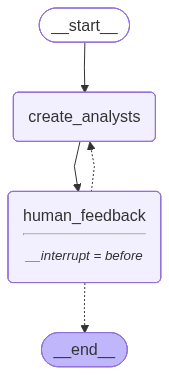

In [11]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

def create_analysts(state: GenerateAnalystsState):
    
    """ Create analysts """
    
    topic=state['topic']
    max_analysts=state['max_analysts']
    human_analyst_feedback=state.get('human_analyst_feedback', '')
        
    # Enforce structured output
    structured_llm = llm.with_structured_output(Perspectives)

    # System message
    system_message = analyst_instructions.format(topic=topic,
                                                            human_analyst_feedback=human_analyst_feedback, 
                                                            max_analysts=max_analysts)

    # Generate question 
    analysts = structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

def human_feedback(state: GenerateAnalystsState):
    """ No-op node that should be interrupted on """
    pass

def should_continue(state: GenerateAnalystsState):
    """ Return the next node to execute """

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analysts"
    
    # Otherwise end
    return END

# Add nodes and edges 
builder = StateGraph(GenerateAnalystsState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", should_continue, ["create_analysts", END])

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [12]:
# Input
max_analysts = 3 
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts,}, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Alice Thompson
Affiliation: Tech Innovations Inc.
Role: AI Framework Specialist
Description: Dr. Thompson focuses on the technical advantages of adopting new AI frameworks, particularly LangGraph, and how they can enhance operational efficiency and scalability.
--------------------------------------------------
Name: Mr. John Carter
Affiliation: Future AI Research Group
Role: AI Ethics Analyst
Description: Mr. Carter examines the ethical implications of AI frameworks like LangGraph, including data privacy, bias, and the societal impact of adopting such technologies.
--------------------------------------------------
Name: Ms. Sarah Lee
Affiliation: Business Strategy Consultants
Role: Business Transformation Advisor
Description: Ms. Lee analyzes the business benefits of implementing LangGraph, focusing on cost savings, productivity improvements, and competitive advantages in the market.
--------------------------------------------------


In [13]:
# Get state and look at next node
state = graph.get_state(thread)
state.next

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst')]


('human_feedback',)

In [14]:
# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"human_analyst_feedback": 
                            "Add in someone from a startup to add an entrepreneur perspective"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1801bb-8494-665a-8002-db3df1dc93ee'}}

In [15]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Alice Thompson
Affiliation: Tech Innovations Inc.
Role: AI Framework Specialist
Description: Dr. Thompson focuses on the technical advantages of adopting new AI frameworks, particularly LangGraph, and how they can enhance operational efficiency and scalability.
--------------------------------------------------
Name: Mr. John Carter
Affiliation: Future AI Research Group
Role: AI Ethics Analyst
Description: Mr. Carter examines the ethical implications of AI frameworks like LangGraph, including data privacy, bias, and the societal impact of adopting such technologies.
--------------------------------------------------
Name: Ms. Sarah Lee
Affiliation: Business Strategy Consultants
Role: Business Transformation Advisor
Description: Ms. Lee analyzes the business benefits of implementing LangGraph, focusing on cost savings, productivity improvements, and competitive advantages in the market.
--------------------------------------------------
Name: Alice Johnson
Affiliation: Tech In

In [16]:
# If we are satisfied, then we simply supply no feedback
further_feedack = None
graph.update_state(thread, {"human_analyst_feedback": 
                            further_feedack}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1801bb-c689-65ac-8004-ff38d83becc4'}}

In [17]:
# Continue the graph execution to end
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [18]:
final_state = graph.get_state(thread)
analysts = final_state.values.get('analysts')

In [19]:
final_state.next

()

In [20]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Alice Johnson
Affiliation: Tech Innovations Inc.
Role: AI Researcher
Description: Alice focuses on the technical aspects of AI frameworks, particularly their scalability and integration capabilities. She is interested in how LangGraph can enhance AI agent performance.
--------------------------------------------------
Name: Michael Chen
Affiliation: Startup Hub
Role: Entrepreneur
Description: Michael represents the startup perspective, emphasizing the practical benefits of adopting LangGraph for rapid development and deployment of AI solutions in a competitive market.
--------------------------------------------------
Name: Dr. Sarah Patel
Affiliation: University of Technology
Role: Academic Researcher
Description: Dr. Patel studies the theoretical implications of AI frameworks, including LangGraph. She is concerned with the ethical considerations and long-term impacts of adopting such technologies.
--------------------------------------------------


## Conduct Interview

### Generate Question

The analyst will ask questions to the expert.

In [21]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [22]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

def generate_question(state: InterviewState):
    """ Node to generate a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]

    # Generate question 
    system_message = question_instructions.format(goals=analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
        
    # Write messages to state
    return {"messages": [question]}

### Generate Answer: Parallelization

The expert will gather information from multiple sources in parallel to answer questions.

For example, we can use:

* Specific web sites e.g., via [`WebBaseLoader`](https://docs.langchain.com/oss/python/integrations/document_loaders/web_base)
* Indexed documents e.g., via [RAG](https://docs.langchain.com/oss/python/langchain/retrieval)
* Web search
* Wikipedia search

You can try different web search tools, like [Tavily](https://tavily.com/).

In [24]:
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("TAVILY_API_KEY")

In [25]:
# Web search tool
from langchain_tavily import TavilySearch  # updated 1.0

tavily_search = TavilySearch(max_results=3)

In [26]:
# Wikipedia search tool
from langchain_community.document_loaders import WikipediaLoader

/tmp/ipykernel_4100049/2780612488.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WikipediaLoader


Now, we create nodes to search the web and wikipedia.

We'll also create a node to answer analyst questions.

Finally, we'll create nodes to save the full interview and to write a summary ("section") of the interview.

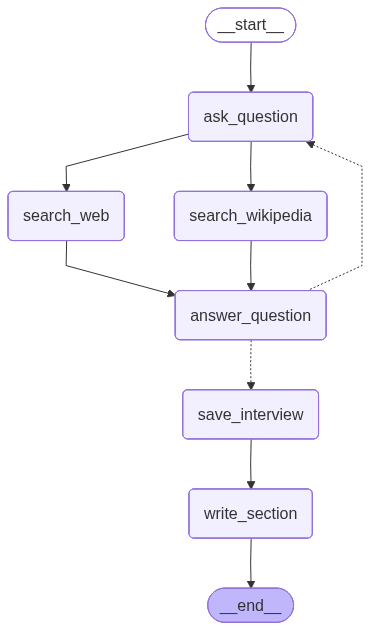

In [27]:
from langchain_core.messages import get_buffer_string

# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
        
First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

def search_web(state: InterviewState):
    
    """ Retrieve docs from web search """

    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    # Search
    #search_docs = tavily_search.invoke(search_query.search_query) # updated 1.0
    data = tavily_search.invoke({"query": search_query.search_query})
    search_docs = data.get("results", data)
    

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

def search_wikipedia(state: InterviewState):
    
    """ Retrieve docs from wikipedia """

    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])

    if not getattr(search_query, "search_query", "").strip():
        return {"context": ["No Wikipedia search query was generated."]}
    
    # Search
    try:
        search_docs = WikipediaLoader(query=search_query.search_query, 
                                      load_max_docs=2).load()
    except Exception as exc:
        return {
            "context": [
                f'<Document source="wikipedia" />\nWikipedia lookup failed: {exc}\n</Document>'
            ]
        }

    if not search_docs:
        return {
            "context": [
                f'<Document source="wikipedia" />\nNo Wikipedia results were returned for query: {search_query.search_query}\n</Document>'
            ]
        }

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

def generate_answer(state: InterviewState):
    
    """ Node to answer a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    # Append it to state
    return {"messages": [answer]}

def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}

def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    return "ask_question"

section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}

# Add nodes and edges 
interview_builder = StateGraph(InterviewState)
interview_builder.add_node("ask_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("search_wikipedia", search_wikipedia)
interview_builder.add_node("answer_question", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

# Flow
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question", "search_web")
interview_builder.add_edge("ask_question", "search_wikipedia")
interview_builder.add_edge("search_web", "answer_question")
interview_builder.add_edge("search_wikipedia", "answer_question")
interview_builder.add_conditional_edges("answer_question", route_messages,['ask_question','save_interview'])
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

# Interview 
memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name="Conduct Interviews")

# View
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [28]:
# Pick one analyst
analysts[0]

Analyst(affiliation='Tech Innovations Inc.', name='Alice Johnson', role='AI Researcher', description='Alice focuses on the technical aspects of AI frameworks, particularly their scalability and integration capabilities. She is interested in how LangGraph can enhance AI agent performance.')

Here, we run the interview passing an index of the llama3.1 paper, which is related to our topic.

In [29]:
from IPython.display import Markdown
messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]
thread = {"configurable": {"thread_id": "1"}}
interview = interview_graph.invoke({"analyst": analysts[0], "messages": messages, "max_num_turns": 2}, thread)
Markdown(interview['sections'][0])

## Enhancing AI Agent Performance with LangGraph

### Summary
As the demand for sophisticated AI agents grows, the need for frameworks that can effectively manage complex interactions and workflows becomes paramount. LangGraph has emerged as a leading solution, particularly noted for its scalability and integration capabilities. This framework allows developers to create stateful, multi-agent applications that leverage large language models (LLMs) in a graph-based architecture. One of the most compelling aspects of LangGraph is its ability to handle complex multi-step reasoning, making it ideal for applications that require agents to backtrack, explore different approaches, or manage multiple conversation threads simultaneously. 

Insights from recent discussions reveal that while there is a learning curve associated with LangGraph, particularly in mastering its node-edge structure, the payoff is significant. Users report that once familiar with the framework, building sophisticated agents becomes intuitive and efficient. The introduction of LangGraph 1.0 in October 2025 marked a significant milestone, providing organizations with a stable, production-grade framework that supports advanced multi-agent orchestration patterns. This allows for persistent state management across sessions and the incorporation of human oversight at critical decision points, addressing a common barrier to deployment in AI systems.

Moreover, LangGraph's architecture facilitates the orchestration of agent interactions, enabling developers to move beyond the limitations of single-turn prompts. This capability is crucial for creating reliable, production-ready AI systems that can operate autonomously while maintaining context and memory. The framework's flexibility and efficiency in managing dynamic workflows have led to its adoption across various industries, with many organizations reporting improved agent performance and reduced errors in real-world applications.

1. [What are the main advantages of choosing LangGraph for AI agent development?](https://community.latenode.com/t/what-are-the-main-advantages-of-choosing-langgraph-for-ai-agent-development/31000)  
2. [LangGraph Agents in Production: Architecture, Costs & Real-World Outcomes](https://www.alphabold.com/langgraph-agents-in-production)  
3. [Building AI Workflows with LangGraph: Practical Use Cases and Examples](https://www.scalablepath.com/ai/langgraph)  
4. [10 Langgraph Projects to Build Intelligent AI Agents](https://www.projectpro.io/article/langgraph-projects-and-examples/1124)  
5. [Building Production-Ready AI Agents with LangGraph: A Real-Life Use Case](https://medium.com/cyberark-engineering/building-production-ready-ai-agents-with-langgraph-a-real-life-use-case-7bda34c7f4e4)  

### Sources
[1] https://community.latenode.com/t/what-are-the-main-advantages-of-choosing-langgraph-for-ai-agent-development/31000  
[2] https://www.alphabold.com/langgraph-agents-in-production  
[3] https://www.scalablepath.com/ai/langgraph  
[4] https://www.projectpro.io/article/langgraph-projects-and-examples/1124  
[5] https://medium.com/cyberark-engineering/building-production-ready-ai-agents-with-langgraph-a-real-life-use-case-7bda34c7f4e4  

### Parallelze interviews: Map-Reduce

We parallelize the interviews via the `Send()` API, a map step.

We combine them into the report body in a reduce step.

### Finalize

We add a final step to write an intro and conclusion to the final report.

In [30]:
import operator
from typing import List, Annotated
from typing_extensions import TypedDict

class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report

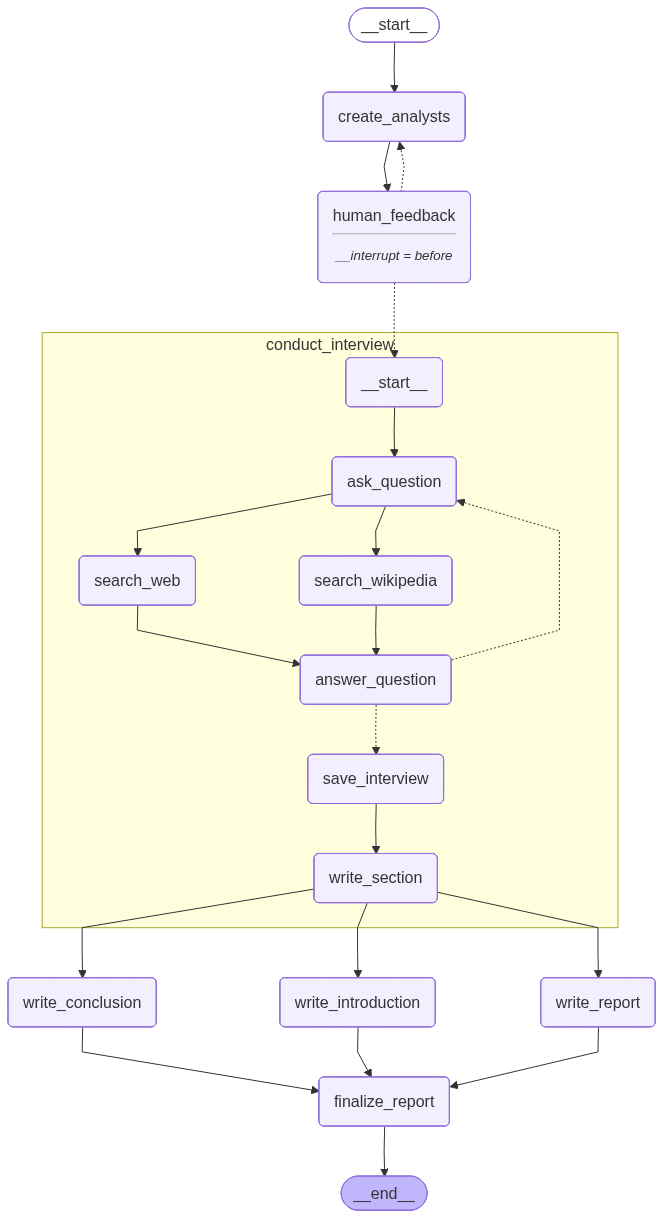

In [31]:
from langgraph.types import Send # updated in 1.0
def initiate_all_interviews(state: ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """    

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"

    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                           "messages": [HumanMessage(
                                               content=f"So you said you were writing an article on {topic}?"
                                           )
                                                       ]}) for analyst in state["analysts"]]

report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

def finalize_report(state: ResearchGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

# Add nodes and edges 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

Let's ask an open-ended question about LangGraph.

In [32]:
# Inputs
max_analysts = 3 
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"topic":topic,
                           "max_analysts":max_analysts}, 
                          thread, 
                          stream_mode="values"):
    
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Alice Thompson
Affiliation: Tech Innovations Inc.
Role: AI Framework Specialist
Description: Dr. Thompson focuses on the technical advantages of adopting LangGraph, emphasizing its scalability and integration capabilities with existing systems.
--------------------------------------------------
Name: Mr. John Carter
Affiliation: Future AI Research Group
Role: AI Ethics Analyst
Description: Mr. Carter examines the ethical implications of using LangGraph, particularly in terms of transparency and accountability in AI decision-making.
--------------------------------------------------
Name: Ms. Sarah Lee
Affiliation: Business Solutions Consultancy
Role: Business Strategy Consultant
Description: Ms. Lee analyzes the business benefits of LangGraph, including cost efficiency, productivity improvements, and competitive advantages in the market.
--------------------------------------------------


In [33]:
# We now update the state as if we are the human_feedback node
graph.update_state(thread, {"human_analyst_feedback": 
                                "Add in the CEO of gen ai native startup"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1801c0-7c1d-65ad-8002-0fca9757493d'}}

In [34]:
# Check
for event in graph.stream(None, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Alice Thompson
Affiliation: Tech Innovations Inc.
Role: AI Framework Specialist
Description: Dr. Thompson focuses on the technical advantages of adopting LangGraph, emphasizing its scalability and integration capabilities with existing systems.
--------------------------------------------------
Name: Mr. John Carter
Affiliation: Future AI Research Group
Role: AI Ethics Analyst
Description: Mr. Carter examines the ethical implications of using LangGraph, particularly in terms of transparency and accountability in AI decision-making.
--------------------------------------------------
Name: Ms. Sarah Lee
Affiliation: Business Solutions Consultancy
Role: Business Strategy Consultant
Description: Ms. Lee analyzes the business benefits of LangGraph, including cost efficiency, productivity improvements, and competitive advantages in the market.
--------------------------------------------------
Name: Alex Johnson
Affiliation: Gen AI Native Startup
Role: CEO
Description: As the CEO o

In [35]:
# Confirm we are happy
graph.update_state(thread, {"human_analyst_feedback": 
                            None}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1801c0-9612-6fab-8004-0c85d3d706b8'}}

In [36]:
# Continue
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

--Node--
conduct_interview
--Node--
conduct_interview
--Node--
conduct_interview
--Node--
write_introduction
--Node--
write_conclusion
--Node--
write_report
--Node--
finalize_report


In [37]:
from IPython.display import Markdown
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

# Unlocking the Power of LangGraph for AI Agents

## Introduction

In the fast-paced world of artificial intelligence, adopting robust frameworks like LangGraph is essential for startups seeking to enhance operational efficiency and foster innovation. This report explores LangGraph's unique graph-based architecture, which excels in managing complex multi-agent workflows and facilitating sophisticated reasoning. We delve into the learning curve associated with mastering LangGraph, the significant advancements introduced with its 1.0 release, and its practical applications across various industries. By examining case studies and the framework's adaptability, we highlight how LangGraph can empower organizations to leverage AI for improved decision-making and competitive advantage.

---


The adoption of LangGraph as an agent framework presents numerous benefits for organizations seeking to enhance operational efficiency and drive innovation in artificial intelligence (AI). LangGraph's graph-based architecture is particularly advantageous for developing sophisticated AI agents capable of managing complex multi-agent workflows. This framework allows for dynamic interactions among agents, enabling them to backtrack, explore various approaches, and handle multiple conversation threads simultaneously, which is essential for addressing intricate problems in real-world applications [1][2].

Despite the initial learning curve associated with LangGraph, users have reported that mastering its node-edge structure leads to the development of highly capable agents. These agents can autonomously manage intricate tasks, reducing the need for constant human oversight and fostering innovation in business processes [3]. The release of LangGraph 1.0 in October 2025 marked a significant milestone, providing organizations with a stable, production-grade framework that supports advanced multi-agent orchestration patterns. This capability is crucial as 57% of organizations have begun deploying AI agents, with a focus on quality over cost [4][5].

LangGraph's architecture not only facilitates the persistence of agents through failures but also incorporates human oversight at critical decision points, enhancing the reliability of AI systems in various applications, including customer service and healthcare [6]. The framework's ability to streamline automation in multi-step processes and enhance decision-making workflows has been highlighted in numerous case studies, showcasing its versatility across different sectors [7][8].

Furthermore, LangGraph's unique capabilities in managing complex workflows and facilitating multi-agent interactions position it as a compelling choice for organizations looking to leverage AI for improved operational efficiency and decision-making. Startups, in particular, can benefit from adopting LangGraph to differentiate themselves in a competitive market, as it enhances the technical capabilities of AI agents and fosters innovation [9].

In summary, LangGraph represents a paradigm shift in AI development, offering organizations the tools necessary to create advanced agents that can effectively tackle complex challenges and drive growth.


---

## Conclusion

In conclusion, adopting LangGraph as an agent framework offers significant advantages for organizations seeking to enhance operational efficiency and drive innovation. Its graph-based architecture facilitates advanced multi-agent orchestration, enabling AI agents to manage complex workflows and engage in nuanced interactions. Despite the initial learning curve, the long-term benefits of mastering LangGraph's capabilities are evident in its ability to support stateful interactions and human oversight. Successful case studies across various industries demonstrate its versatility and effectiveness. As the demand for sophisticated AI solutions grows, LangGraph stands out as a pivotal tool for startups aiming to gain a competitive edge in the evolving landscape of artificial intelligence.

## Sources
[1] https://community.latenode.com/t/what-are-the-main-advantages-of-choosing-langgraph-for-ai-agent-development/31000  
[2] https://www.alphabold.com/langgraph-agents-in-production  
[3] https://www.langchain.com/langgraph  
[4] https://scouts.yutori.com/91e0b0d3-444a-4eee-9ccc-26cf0a8fc313  
[5] https://medium.com/@garima_yadav/real-world-applications-and-case-studies-with-langgraph-from-theory-to-practice-7a6ffd2e8e1b  
[6] https://www.scalablepath.com/ai/langgraph  
[7] https://temporal.io/blog/prototype-to-prod-ready-agentic-ai-grid-dynamics  
[8] https://www.youtube.com/watch?v=t4GCJB-qMN8  
[9] https://www.youtube.com/watch?v=aHCDrAbH_go

We can look at the trace:

https://smith.langchain.com/public/2933a7bb-bcef-4d2d-9b85-cc735b22ca0c/r